In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
PROJECT_DIR = "/content/drive/MyDrive/computervisionproject"

DATASET_DIR = os.path.join(PROJECT_DIR, "dataset", "processed_dataset")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

In [5]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 12121 files belonging to 3 classes.
Found 1514 files belonging to 3 classes.
Found 1518 files belonging to 3 classes.


In [7]:
baseline_path = os.path.join(
    MODEL_DIR,
    "baseline.keras"
)

model = tf.keras.models.load_model(baseline_path)

print("Baseline model loaded.")

Baseline model loaded.


In [8]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,102 (15.49 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 7,688 (30.04 KB)

In [9]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.trainable)

0 input_layer_1 True
1 sequential True
2 efficientnetb0 False
3 global_average_pooling2d True
4 dropout True
5 dense True


In [10]:
base_model = model.layers[2]

base_model.trainable = True

print("Base model is now trainable.")

Base model is now trainable.


In [11]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Last 30 layers will be fine-tuned.")

Last 30 layers will be fine-tuned.


In [12]:
trainable = 0

for layer in model.layers:
    if layer.trainable:
        trainable += 1
        print(layer.name)

print("\nTrainable top-level layers:", trainable)

input_layer_1
sequential
efficientnetb0
global_average_pooling2d
dropout
dense

Trainable top-level layers: 6


In [13]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [14]:
checkpoint = ModelCheckpoint(

    filepath=os.path.join(
        MODEL_DIR,
        "best_model.keras"
    ),

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

early = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

reduce = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    verbose=1

)

In [15]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10,

    callbacks=[
        checkpoint,
        early,
        reduce
    ]

)

Epoch 1/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7275 - loss: 0.6656
Epoch 1: val_accuracy improved from None to 0.90225, saving model to /content/drive/MyDrive/computervisionproject/models/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/computervisionproject/models/best_model.keras
379/379 ━━━━━━━━━━━━━━━━━━━━ 2109s 6s/step - accuracy: 0.7843 - loss: 0.5293 - val_accuracy: 0.9022 - val_loss: 0.2795 - learning_rate: 1.0000e-05
Epoch 2/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8717 - loss: 0.3460
Epoch 2: val_accuracy improved from 0.90225 to 0.92272, saving model to /content/drive/MyDrive/computervisionproject/models/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/computervisionproject/models/best_model.keras
379/379 ━━━━━━━━━━━━━━━━━━━━ 75s 197ms/step - accuracy: 0.8765 - loss: 0.3303 - val_accuracy: 0.9227 - val_loss: 0.2197 - learning_rate: 1.0000e-05
Epoch 3/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 17

In [16]:
model.save(
    os.path.join(
        MODEL_DIR,
        "best_model_final.keras"
    )
)

print("Fine-tuned model saved.")

Fine-tuned model saved.


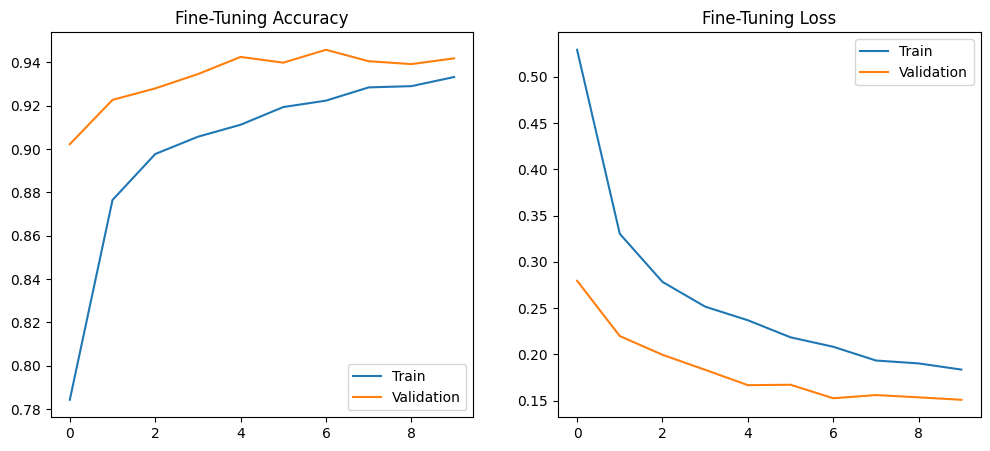

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Fine-Tuning Accuracy")

plt.legend(["Train","Validation"])

plt.subplot(1,2,2)

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Fine-Tuning Loss")

plt.legend(["Train","Validation"])

plt.show()

In [18]:
loss, accuracy = model.evaluate(test_ds)

print(f"\nFine-Tuned Test Accuracy: {accuracy:.4f}")

48/48 ━━━━━━━━━━━━━━━━━━━━ 277s 6s/step - accuracy: 0.9433 - loss: 0.1540

Fine-Tuned Test Accuracy: 0.9433
